In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")
data = pd.read_csv('медик.csv', sep=",")
# Первые 5 строк датасета
data.head()

,id,full_name,age,gender,smoking_status,bmi,blood_pressure,glucose_levels,condition
0,1,User0001,NaN,male,Non-Smoker,NaN,NaN,NaN,Pneumonia
1,2,User0002,30.0,male,Non-Smoker,NaN,105.315064,NaN,Diabetic
2,3,User0003,18.0,male,Non-Smoker,35.612486,NaN,NaN,Pneumonia
3,4,User0004,NaN,male,Non-Smoker,NaN,99.119829,NaN,Pneumonia
4,5,User0005,76.0,male,Non-Smoker,NaN,NaN,NaN,Diabetic


In [4]:
# размер набора данных
data.shape

(10000, 9)

In [5]:
# типы колонок
data.dtypes

,0
id,int64
full_name,object
age,float64
gender,object
smoking_status,object
bmi,float64
blood_pressure,float64
glucose_levels,float64
condition,object


In [6]:
# пропущенные значения
data.isnull().sum()

,0
id,0
full_name,0
age,4555
gender,0
smoking_status,0
bmi,5348
blood_pressure,6234
glucose_levels,5244
condition,0


In [7]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 10000


In [8]:
# Удаление колонок, содержащих пустые значения
data_new_1 = data.dropna(axis=1, how='any')
(data.shape, data_new_1.shape)

((10000, 9), (10000, 5))

In [9]:
# Что осталось после удаления столбцов
data_new_1.head()

,id,full_name,gender,smoking_status,condition
0,1,User0001,male,Non-Smoker,Pneumonia
1,2,User0002,male,Non-Smoker,Diabetic
2,3,User0003,male,Non-Smoker,Pneumonia
3,4,User0004,male,Non-Smoker,Pneumonia
4,5,User0005,male,Non-Smoker,Diabetic


In [10]:
# Удаление строк, содержащих пустые значения
data_new_2 = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((10000, 9), (446, 9))

In [11]:
# Что осталось после удаления строк
data_new_2.head()

,id,full_name,age,gender,smoking_status,bmi,blood_pressure,glucose_levels,condition
22,23,User0023,49.0,male,Non-Smoker,28.025453,119.212083,150.628025,Pneumonia
63,64,User0064,43.0,male,Non-Smoker,34.978378,107.052200,190.482674,Diabetic
84,85,User0085,52.0,male,Smoker,25.024378,131.071030,185.997004,Diabetic
89,90,User0090,70.0,male,Smoker,39.249085,113.848795,124.264664,Pneumonia
153,154,User0154,66.0,male,Smoker,24.333718,173.787158,130.727447,Diabetic


In [12]:
# Заполнение всех пропущенных значений нулями
# В данном случае это мб некорректно, потому что ставить 0 в строке с возрастом это сомнительно (?)
data_new_3 = data.fillna(0)
data_new_3.head()

,id,full_name,age,gender,smoking_status,bmi,blood_pressure,glucose_levels,condition
0,1,User0001,0.0,male,Non-Smoker,0.000000,0.000000,0.0,Pneumonia
1,2,User0002,30.0,male,Non-Smoker,0.000000,105.315064,0.0,Diabetic
2,3,User0003,18.0,male,Non-Smoker,35.612486,0.000000,0.0,Pneumonia
3,4,User0004,0.0,male,Non-Smoker,0.000000,99.119829,0.0,Pneumonia
4,5,User0005,76.0,male,Non-Smoker,0.000000,0.000000,0.0,Diabetic


In [13]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
num_cols = []
for col in data.columns:
    # Количество пустых значений
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка age. Тип данных float64. Количество пустых значений 4555, 45.55%.
Колонка bmi. Тип данных float64. Количество пустых значений 5348, 53.48%.
Колонка blood_pressure. Тип данных float64. Количество пустых значений 6234, 62.34%.
Колонка glucose_levels. Тип данных float64. Количество пустых значений 5244, 52.44%.


In [14]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,age,bmi,blood_pressure,glucose_levels
0,NaN,NaN,NaN,NaN
1,30.0,NaN,105.315064,NaN
2,18.0,35.612486,NaN,NaN
3,NaN,NaN,99.119829,NaN
4,76.0,NaN,NaN,NaN
...,...,...,...,...
9995,NaN,25.029002,152.540355,137.551451
9996,NaN,27.017487,NaN,NaN
9997,23.0,NaN,148.833321,173.931480
9998,NaN,NaN,NaN,NaN


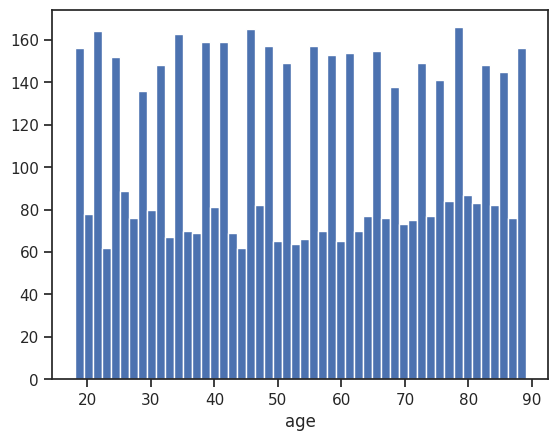

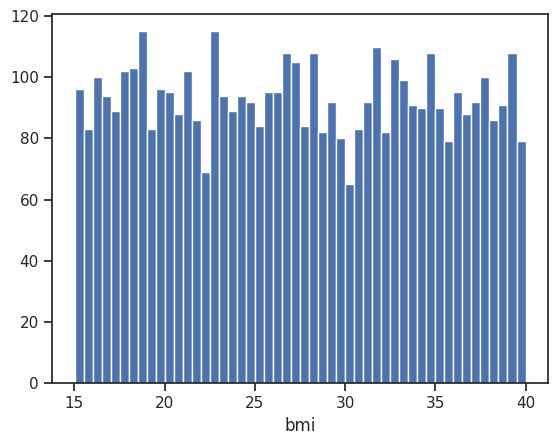

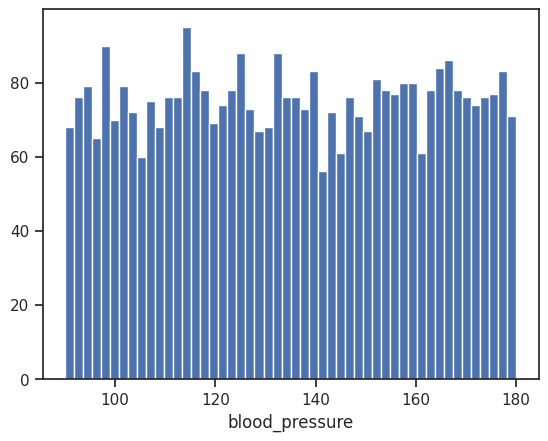

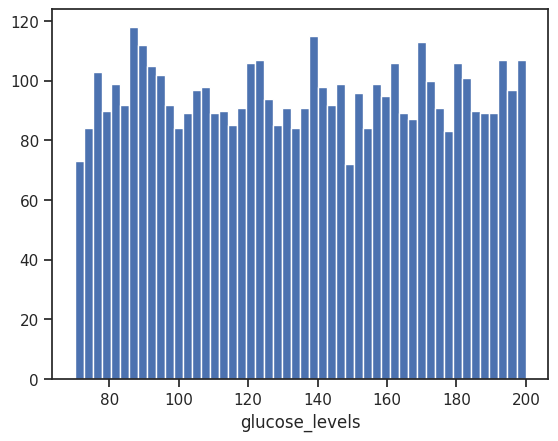

In [15]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [16]:
# Выводим только столбец bmi
data_num_bmi = data_num[['bmi']]
data_num_bmi.head()

,bmi
0,NaN
1,NaN
2,35.612486
3,NaN
4,NaN


In [17]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
# Фильтр для проверки заполнения пустых значений (если правда, значит, пусто)
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_bmi)
mask_missing_values_only

array([[ True],
       [ True],
       [False],
       ...,
       [ True],
       [ True],
       [False]])

In [18]:
strategies=['mean', 'median', 'most_frequent']
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_bmi)
    return data_num_imp[mask_missing_values_only]
strategies[0], test_num_impute(strategies[0])

('mean',
 array([27.42341987, 27.42341987, 27.42341987, ..., 27.42341987,
        27.42341987, 27.42341987]))

In [19]:
strategies[1], test_num_impute(strategies[1])

('median',
 array([27.32620403, 27.32620403, 27.32620403, ..., 27.32620403,
        27.32620403, 27.32620403]))

In [20]:
strategies[2], test_num_impute(strategies[2])

('most_frequent',
 array([15.01211867, 15.01211867, 15.01211867, ..., 15.01211867,
        15.01211867, 15.01211867]))

In [21]:
# Более сложная функция, которая позволяет задавать колонку и вид импьютации
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]

    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)

    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)

    filled_data = data_num_imp[mask_missing_values_only]

    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]
data[['blood_pressure']].describe()

,blood_pressure
count,3766.000000
mean,135.209429
std,26.041531
min,90.009620
25%,113.107754
50%,134.821040
75%,157.949509
max,179.999359


In [22]:
test_num_impute_col(data, 'blood_pressure', strategies[0])

('blood_pressure',
 'mean',
 6234,
 np.float64(135.2094286936411),
 np.float64(135.2094286936411))

In [23]:
test_num_impute_col(data, 'blood_pressure', strategies[1])

('blood_pressure',
 'median',
 6234,
 np.float64(134.8210403297863),
 np.float64(134.8210403297863))

In [24]:
test_num_impute_col(data, 'blood_pressure', strategies[2])

('blood_pressure',
 'most_frequent',
 6234,
 np.float64(90.00961982252267),
 np.float64(90.00961982252267))

In [25]:
# Выберем категориальные колонки с пропущенными значениями (их нет...)
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))
if len(cat_cols) == 0:
    print('Нет столбцов с категориальными признаками и пустыми значениями')


Нет столбцов с категориальными признаками и пустыми значениями


In [26]:
cat_enc = pd.DataFrame({'c1': data['gender']})
cat_enc

,c1
0,male
1,male
2,male
3,male
4,male
...,...
9995,male
9996,male
9997,male
9998,female


In [27]:
# Использование LabelEncoder
from sklearn.preprocessing import LabelEncoder
cat_enc['c1'].unique()

array(['male', 'female'], dtype=object)

In [28]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc['c1'])
le.classes_

array(['female', 'male'], dtype=object)

In [29]:
cat_enc_le

array([1, 1, 1, ..., 1, 0, 1])

In [30]:
np.unique(cat_enc_le)

array([0, 1])

In [31]:
# Использование OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder
data_oe = data[['gender', 'smoking_status', 'condition']]
data_oe.head()

,gender,smoking_status,condition
0,male,Non-Smoker,Pneumonia
1,male,Non-Smoker,Diabetic
2,male,Non-Smoker,Pneumonia
3,male,Non-Smoker,Pneumonia
4,male,Non-Smoker,Diabetic


In [32]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['male', 'Non-Smoker', 'Pneumonia'],
       ['male', 'Non-Smoker', 'Diabetic'],
       ['male', 'Non-Smoker', 'Pneumonia'],
       ...,
       ['male', 'Smoker', 'Pneumonia'],
       ['female', 'Non-Smoker', 'Pneumonia'],
       ['male', 'Non-Smoker', 'Diabetic']], dtype=object)

In [33]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[1., 0., 2.],
       [1., 0., 1.],
       [1., 0., 2.],
       ...,
       [1., 1., 2.],
       [0., 0., 2.],
       [1., 0., 1.]])

In [34]:
# Уникальные значения 1 признака
np.unique(cat_enc_oe[:, 0])

array([0., 1.])

In [35]:
# Уникальные значения 2 признака
np.unique(cat_enc_oe[:, 1])

array([0., 1.])

In [36]:
# Уникальные значения 3 признака
np.unique(cat_enc_oe[:, 2])

array([0., 1., 2.])

In [37]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['female', 'male'], dtype=object),
 array(['Non-Smoker', 'Smoker'], dtype=object),
 array(['Cancer', 'Diabetic', 'Pneumonia'], dtype=object)]

In [38]:
# Обратное преобразование (?)
oe.inverse_transform(cat_enc_oe)

array([['male', 'Non-Smoker', 'Pneumonia'],
       ['male', 'Non-Smoker', 'Diabetic'],
       ['male', 'Non-Smoker', 'Pneumonia'],
       ...,
       ['male', 'Smoker', 'Pneumonia'],
       ['female', 'Non-Smoker', 'Pneumonia'],
       ['male', 'Non-Smoker', 'Diabetic']], dtype=object)

In [40]:
# пример шкалы порядка 'small' < 'medium' < 'large'
sizes = ['small', 'medium', 'large', 'small', 'medium', 'large', 'small', 'medium', 'large']
pd_sizes = pd.DataFrame(data={'sizes':sizes})
pd_sizes['sizes_codes'] = pd_sizes['sizes'].map({'small':1, 'medium':2, 'large':3})
pd_sizes

,sizes,sizes_codes
0,small,1
1,medium,2
2,large,3
3,small,1
4,medium,2
5,large,3
6,small,1
7,medium,2
8,large,3


In [41]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(cat_enc[['c1']])
cat_enc.shape

(10000, 1)

In [42]:
cat_enc_ohe.shape

(10000, 2)

In [43]:
cat_enc_ohe

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10000 stored elements and shape (10000, 2)>

In [44]:
cat_enc_ohe.todense()[0:10]

matrix([[0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.]])

In [45]:
cat_enc.head(10)

,c1
0,male
1,male
2,male
3,male
4,male
5,male
6,male
7,male
8,male
9,male


In [46]:
pd.get_dummies(cat_enc).head()

,c1_female,c1_male
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


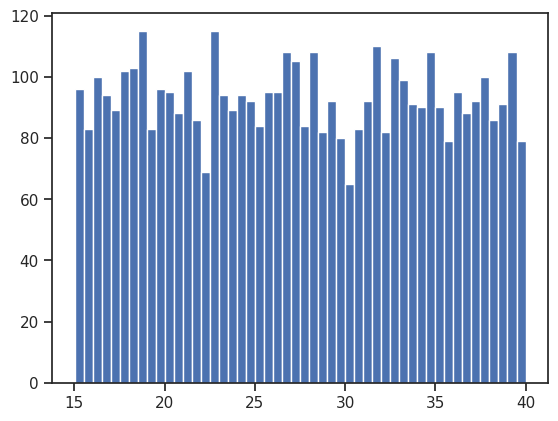

In [50]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
# minmax маштабирование
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['bmi']])
plt.hist(data['bmi'], 50)
plt.show()

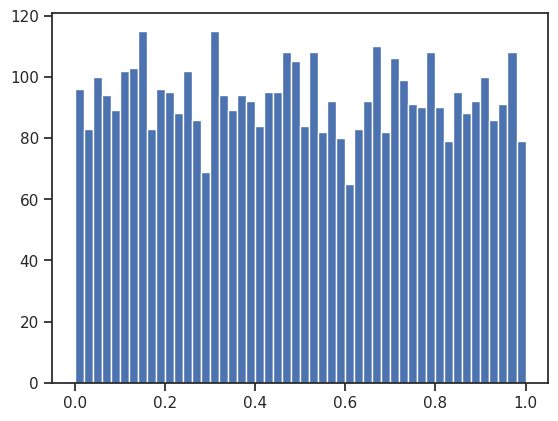

In [51]:
plt.hist(sc1_data, 50)
plt.show()

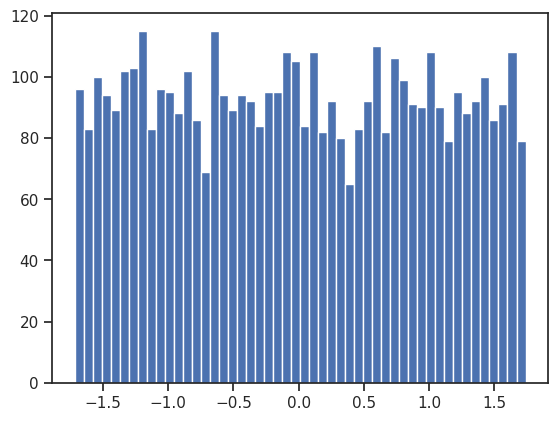

In [52]:
# Масштабирование данных на основе Z-оценки
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['bmi']])
plt.hist(sc2_data, 50)
plt.show()